In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/Users/imanemokhtatif/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Binary matrix of GO presence/absence
X = pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/X.csv')

In [3]:
data = pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
print(len(data['mutant_ID'].unique()),
len(data['mutated_genes'].unique()))

/var/folders/_k/7_jrlrl97z33vpfdszcnhl780000gn/T/ipykernel_11518/2998361949.py:1: DtypeWarning: Columns (1,366,367,368,369,462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')


1192 650


In [4]:
print(X.shape)
X_num = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.int64)

# genes-per-GO (column sums)
go_counts = X_num.sum(axis=0).astype(int)
# distribution: “k genes → how many GO terms”
dist = go_counts.value_counts().sort_index()
print("n_genes -> n_GO_terms")
print(dist.to_string())
dist_df = dist.rename_axis("n_genes").reset_index(name="n_GO_terms")


(371, 793)
n_genes -> n_GO_terms
0        1
1      446
2      116
3       34
4       25
5       18
6       24
7       16
8        6
9        9
10       7
11       3
12      10
13       8
14       6
15       5
16       4
17       2
18       4
19       1
20       2
21       1
22       2
23       5
25       2
27       2
28       4
29       5
30       1
31       2
32       1
35       1
37       1
38       1
40       1
44       1
45       1
47       1
48       2
57       1
59       1
60       1
68       1
82       1
90       1
94       1
105      1
124      1
148      1
155      1
246      1


## GO test

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef

from scipy.stats import ttest_1samp
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
from matplotlib_venn import venn2
from scipy.stats import ttest_ind
import math
from scipy.stats import t
import empyrikos as eb

In [ ]:
phase2_df=pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv',
                      low_memory=False)
#phase2_df = df_aug
phase2_df['y2_slope_select']= phase2_df['y2_slope']
phase2_df = phase2_df[~phase2_df['plate'].astype(str).str.startswith('99')]

#### shrinkage

In [ ]:
# X: binary matrix (rows=genes, cols=GO terms), index = mutated_genes
# mutant_df: columns [mutated_genes, light_regime, plate, y2_slope_select]
# wt_df: same columns for WT
X = pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/X.csv')
X = X.set_index('mutated_genes')
wt_df = phase2_df[phase2_df['mutant_ID'] == 'WT']
mutant_df = phase2_df[phase2_df['mutant_ID'] != 'WT']

#go_to_genes = {go: set(X.index[X[go]==1]) for go in X.columns}
go_to_genes = {go: set(X.index[X[go]==1]) for go in X.columns if X[go].sum() >= 0}

print("genes in X ∩ data:", len(set(X.index) & set(mutant_df['mutated_genes'])))
print("nonempty GO cols:", (X.sum(axis=0)>0).sum())
print("has WT per regime:", wt_df.groupby('light_regime')['plate'].nunique())


go_results = []
for regime, dfR in mutant_df.groupby('light_regime'):
    for go, genes in go_to_genes.items():
        g = dfR[dfR['mutated_genes'].isin(genes)][['plate','y2_slope_select']].dropna()
        if g.empty: 
            continue
        go_plate_means = g.groupby('plate')['y2_slope_select'].mean()
        deltas = []
        for plate, val in go_plate_means.items():
            wt_vals = wt_df[(wt_df['light_regime']==regime)&(wt_df['plate']==plate)]['y2_slope_select'].dropna()
            if wt_vals.empty: 
                continue
            deltas.append(val - wt_vals.mean())
        if len(deltas) < 2:
            continue
        deltas = np.array(deltas, float)
        n = len(deltas)
        se_hat = deltas.std(ddof=1)/np.sqrt(n)
        go_results.append({
            'GO_term': go, 'light_regime': regime, 'n_replicates': n,
            'delta_mean': deltas.mean(), 'se_hat': se_hat, 'df': n-1, 'se_hat_sq': se_hat**2
        })

paired_go_df = pd.DataFrame(go_results)

fits, rows = {}, []
for regime, g in paired_go_df.groupby("light_regime"):
    r = eb.epb_ttest(
        beta_hat=g["delta_mean"].to_numpy(),
        se_hat_squared=g["se_hat_sq"].to_numpy(),
        df=g["df"].to_numpy(),
        alpha=0.05,
    )
    fits[regime] = r
    gg = g.copy()
    gg["p_value"] = getattr(r, "pvalues", np.nan)
    gg["p_adj"]   = getattr(r, "adj_pvalues", np.nan)
    rows.append(gg)

epb_go_by_regime = pd.concat(rows, ignore_index=True)


genes in X ∩ data: 271
nonempty GO cols: 792
has WT per regime: light_regime
10min-10min     7
1min-1min      10
1min-5min       9
20h_HL          9
20h_ML          9
2h-2h           9
30s-30s         9
5min-5min       9
Name: plate, dtype: int64
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython

 iter        p_obj        d_obj |  abs_gap    x_feas    z_feas |      tau       kap        mu | dir_res     prox  step     alpha
    0   3.9481e-02  -2.3012e+02 | 1.66e+03  9.70e+01  1.09e+00 | 1.00e+00  1.00e+00  1.00e+00 |
    1  -3.2318e+00  -2.3698e+02 | 1.49e+03  9.86e+01  1.11e+00 | 8.86e-01  1.02e+00  9.00e-01 | 1.8e-12  4.8e-01  co-a  1.00e-01
    2  -7.8317e+00  -2.4386e+02 | 1.34e+03  9.96e+01  1.12e+00 | 7.89e-01  1.03e+00  8.10e-01 | 4.8e-13  2.6e-01  co-a  1.00e-01
    3  -1.3873e+01  -2.5083e+02 | 1.21e+03  1.00e+02  1.13e+00 | 7.07e-01  1.03e+00  7.29e-01 | 1.7e-12  6.2e-02  co-a  1.00e-01
    4  -4.7737e+01  -2.838

### No shrinkage ((huuge p_adj))

In [ ]:
from scipy import stats
import statsmodels.stats.multitest as smm

go_results = []
for regime, dfR in mutant_df.groupby('light_regime'):
    wtR = wt_df[(wt_df['light_regime']==regime) & wt_df['y2_slope_select'].notna()]
    wt_plate_mean = wtR.groupby('plate')['y2_slope_select'].mean()
    for go, genes in go_to_genes.items():
        g = dfR[dfR['mutated_genes'].isin(genes)]
        if g.empty:
            continue
        go_plate_mean = g.groupby('plate')['y2_slope_select'].mean()
        common = go_plate_mean.index.intersection(wt_plate_mean.index)
        if len(common) < 2:
            continue
        deltas = (go_plate_mean[common] - wt_plate_mean[common]).to_numpy(float)
        tstat, pval = stats.ttest_1samp(deltas, 0)
        go_results.append({
            'GO_term': go,
            'light_regime': regime,
            'n_replicates': len(deltas),
            'delta_mean': deltas.mean(),
            'se_hat': deltas.std(ddof=1)/np.sqrt(len(deltas)),
            'tstat': tstat,
            'p_value': pval
        })

paired_go_df = pd.DataFrame(go_results)
paired_go_df['p_adj'] = smm.multipletests(paired_go_df['p_value'], method='fdr_bh')[1]
print(paired_go_df)

In [ ]:
def plot_go_volcano_grid(
    go_stats,
    interesting_gos=None,
    fdr_threshold=0.05,
    effect_threshold=None,
    n_cols=4
):
    regimes = ['20h_HL',"20h_ML","2h-2h",'10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']#sorted(go_stats['light_regime'].unique())
    n_rows = int(np.ceil(len(regimes) / n_cols))
    # interesting_gos = set() if interesting_gos is None else set(interesting_gos)

    # cmap = plt.cm.get_cmap('tab10', max(1, len(interesting_gos)))
    # go_color_map = {go: cmap(i % 10) for i, go in enumerate(sorted(interesting_gos))}
    all_gos = sorted(go_stats['GO_term'].dropna().unique())
    cmap = plt.cm.get_cmap('tab20', len(all_gos))  # plus de couleurs
    go_color_map = {go: cmap(i) for i, go in enumerate(all_gos)}


    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, regime in enumerate(regimes):
        ax = axes[i]
        df = go_stats[go_stats['light_regime'] == regime].copy()
        df['neglog10_fdr'] = -np.log10(df['p_adj'].clip(lower=1e-300))
        df['effect_size']  = df['delta_mean']

        ax.scatter(df['effect_size'], df['neglog10_fdr'],
                   c='lightgray', alpha=0.6, s=20, edgecolors='none')

        if interesting_gos:
            sub = df[df['GO_term'].isin(interesting_gos)]
            ax.scatter(sub['effect_size'], sub['neglog10_fdr'],
                       c=sub['GO_term'].map(go_color_map),
                       alpha=0.95, s=35, edgecolors='black', linewidths=0.3)

        ax.axhline(-np.log10(fdr_threshold), linestyle='--', color='black')
        if effect_threshold is not None:
            ax.axvline(-abs(effect_threshold), linestyle='--', color='blue')
            ax.axvline( abs(effect_threshold), linestyle='--', color='blue')

        ax.set_title(regime)
        ax.set_xlabel('Effect Size (Mutant - WT)')
        if i % n_cols == 0:
            ax.set_ylabel('-log10(FDR adj)')
        ax.grid(True, alpha=0.2)
        df['color'] = df['GO_term'].map(go_color_map)
        ax.scatter(df['effect_size'], df['neglog10_fdr'],
                c=df['color'], alpha=0.95, s=25, edgecolors='black')
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # if interesting_gos:
    #     handles = [plt.Line2D([0], [0], marker='o', color='w',
    #                           markerfacecolor=go_color_map[g], markersize=8, label=g,
    #                           markeredgecolor='black', markeredgewidth=0.3)
    #                for g in sorted(interesting_gos)]
    #     fig.legend(handles=handles, loc='center right', title="GO terms")



    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.suptitle('Volcano Plots by Light Regime (GO-level) (no min genes)', fontsize=16, y=1.02)
    plt.show()


/var/folders/_k/7_jrlrl97z33vpfdszcnhl780000gn/T/ipykernel_44784/3972719014.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_gos))  # plus de couleurs


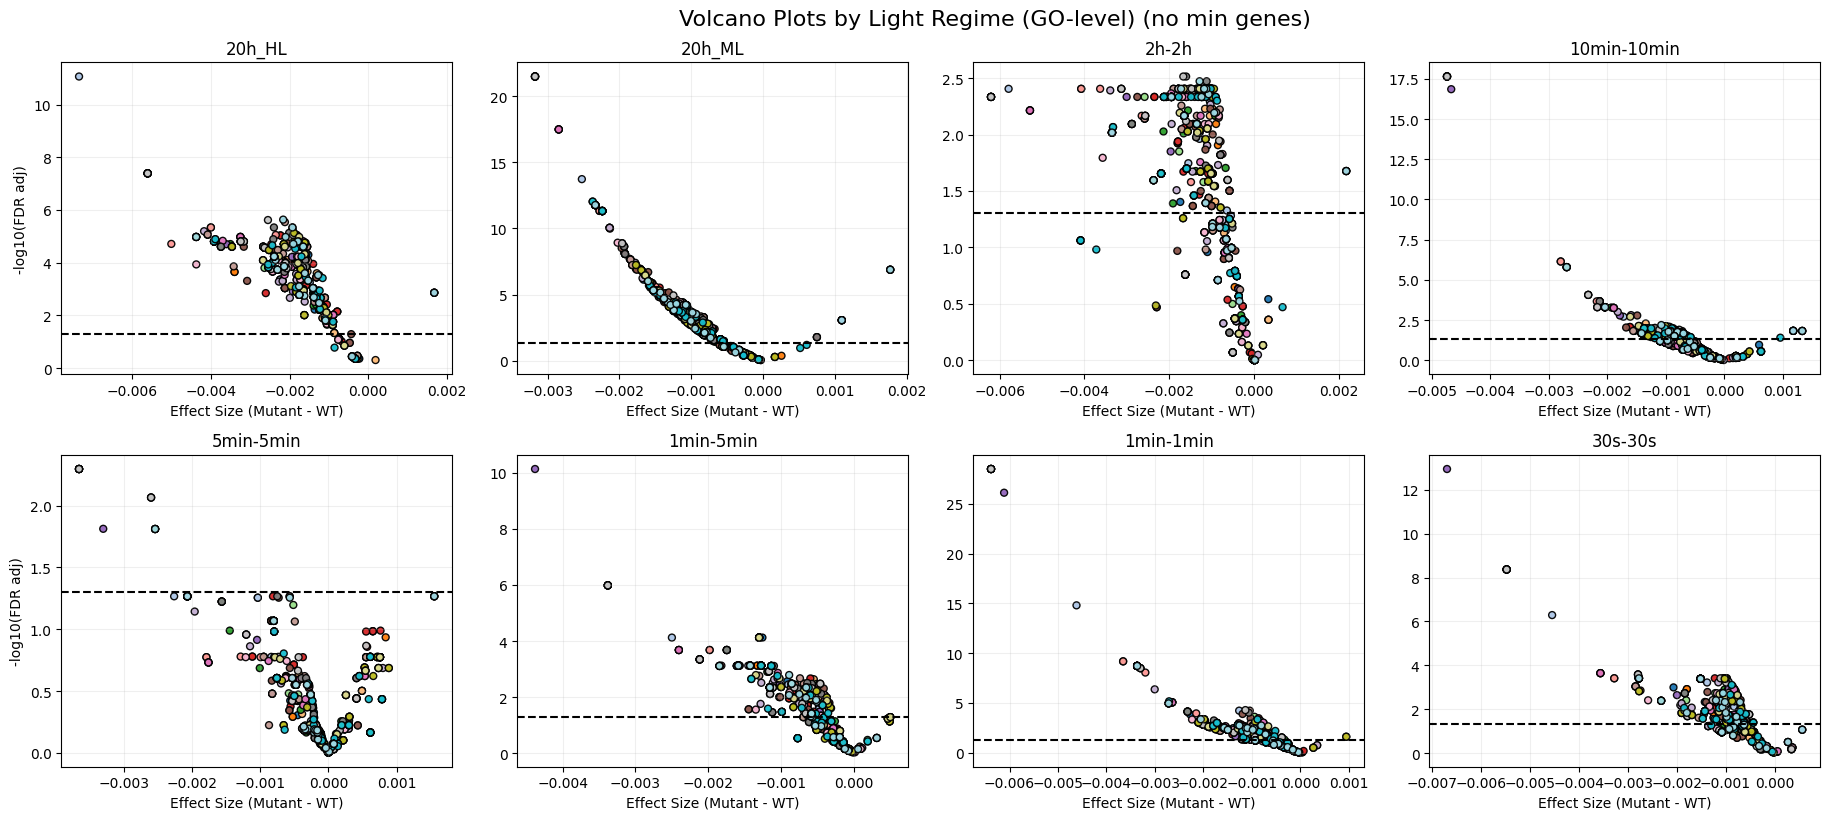

In [ ]:

#interesting = [ "Cre12.g531900","Cre16.g661200","Cre07.g314800","Cre13.g588150", "Cre06.g278110","Cre05.g235800","Cre02.g105350","Cre13.g581900", "Cre07.g323450","Cre15.g635800" ]
interesting = [f"WT{i}"  for i in range(1,4)]
plot_go_volcano_grid(epb_go_by_regime, interesting_gos="", fdr_threshold=0.05, effect_threshold=None, n_cols=4)

In [ ]:
# Inputs:
# epb_go_by_regime: [GO_term, light_regime, p_adj, ...]
# signif_genes: [mutated_genes, light_regime, p_adj, ...]  (gene-level results)
# X: binary matrix of GO annotations (make index = mutated_genes if needed)
signif_genes = pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/significant_genes.csv')
# ensure X indexed by genes (if not already)
if 'mutated_genes' in X.columns:
    X = (X.dropna(subset=['mutated_genes'])
           .drop_duplicates('mutated_genes')
           .set_index('mutated_genes'))
X = X.astype(bool)

# set of significant genes per regime
sig_genes_by_regime = (
    signif_genes[signif_genes['p_adj'] < 0.05]
    .groupby('light_regime')['mutated_genes']
    .apply(set).to_dict()
)

# top-k GO per regime
top_k = 10
rows = []
for regime, g in epb_go_by_regime.dropna(subset=['p_adj']).groupby('light_regime'):
    g = g.sort_values('p_adj')#.head(top_k)
    sig_set = sig_genes_by_regime.get(regime, set())
    for _, r in g.iterrows():
        go = r['GO_term']
        genes = set(X.index[X[go]]) if go in X.columns else set()
        rows.append({
            'light_regime': regime,
            'GO_term': go,
            'p_adj': float(r['p_adj']),
            'n_genes_in_X': int(len(genes)),
            'n_sig_genes_overlap': int(len(genes & sig_set)),
        })

summary_go = pd.DataFrame(rows).sort_values(['light_regime','p_adj'])
print(summary_go)
summary_go.to_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/GO_pairedttest_results(min1gene).csv')

     light_regime     GO_term         p_adj  n_genes_in_X  n_sig_genes_overlap
0     10min-10min  GO:0016053  2.241180e-18             1                    1
1     10min-10min  GO:0044283  2.241180e-18             2                    1
2     10min-10min  GO:0016835  2.241180e-18             2                    1
3     10min-10min  GO:0003856  2.241180e-18             1                    1
4     10min-10min  GO:0016838  2.241180e-18             1                    1
...           ...         ...           ...           ...                  ...
5422    5min-5min  GO:0003700  9.945757e-01             7                    0
5423    5min-5min  GO:0140110  9.945757e-01             7                    0
5424    5min-5min  GO:0005634  9.945757e-01             5                    0
5425    5min-5min  GO:0008104  9.945757e-01             4                    0
5426    5min-5min  GO:0008270  9.957035e-01            20                    0

[5427 rows x 5 columns]


In [ ]:
summary_go = pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/GO_pairedttest_results(min3gene).csv')
support_counts = summary_go['n_sig_genes_overlap'].value_counts().sort_index()
top_hits = summary_go.sort_values('p_adj').groupby('light_regime').head(3)
print(top_hits)


      Unnamed: 0 light_regime     GO_term         p_adj  n_genes_in_X  \
226          226    1min-1min  GO:0008757  1.468386e-08             4   
904          904       20h_ML  GO:0008757  2.717136e-08             4   
907          907       20h_ML  GO:0006082  2.915051e-08             3   
906          906       20h_ML  GO:0019752  2.915051e-08             3   
452          452    1min-5min  GO:0008757  4.212272e-08             4   
678          678       20h_HL  GO:0043412  3.723339e-06            15   
683          683       20h_HL  GO:1901265  4.524833e-06            13   
681          681       20h_HL  GO:1901363  4.524833e-06            14   
1356        1356      30s-30s  GO:0008757  4.933710e-06             4   
227          227    1min-1min  GO:0140098  1.559435e-05             3   
453          453    1min-5min  GO:0003723  1.712094e-05             6   
0              0  10min-10min  GO:0008757  2.453625e-05             4   
1              1  10min-10min  GO:0019752  2.910470

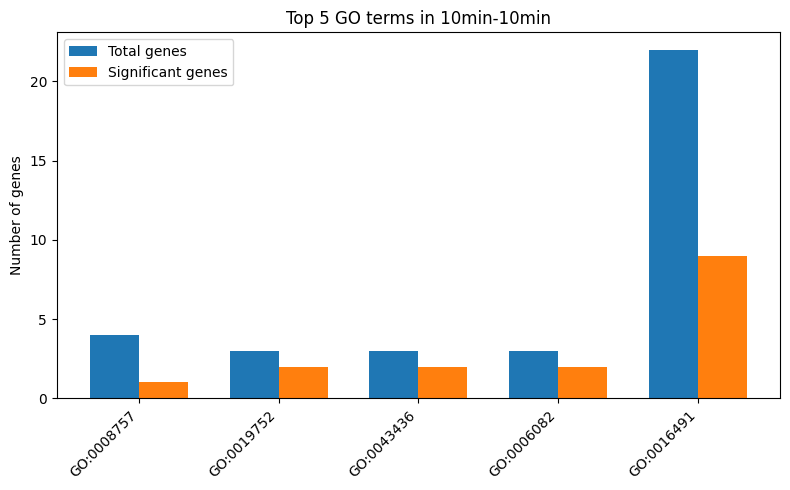

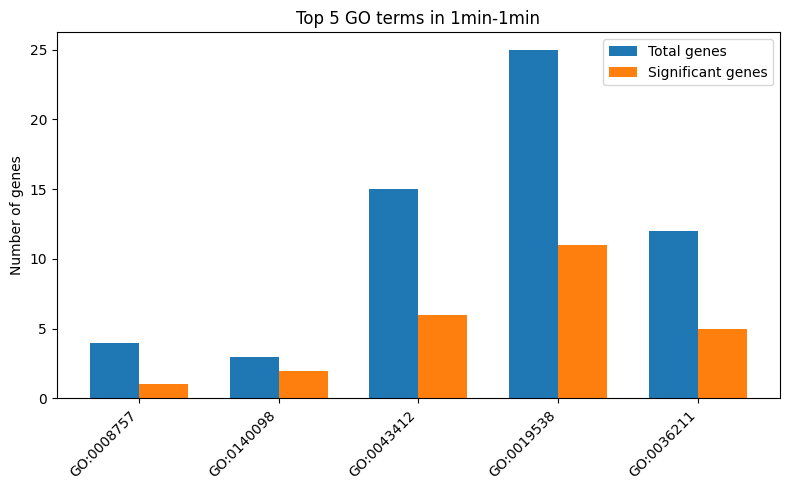

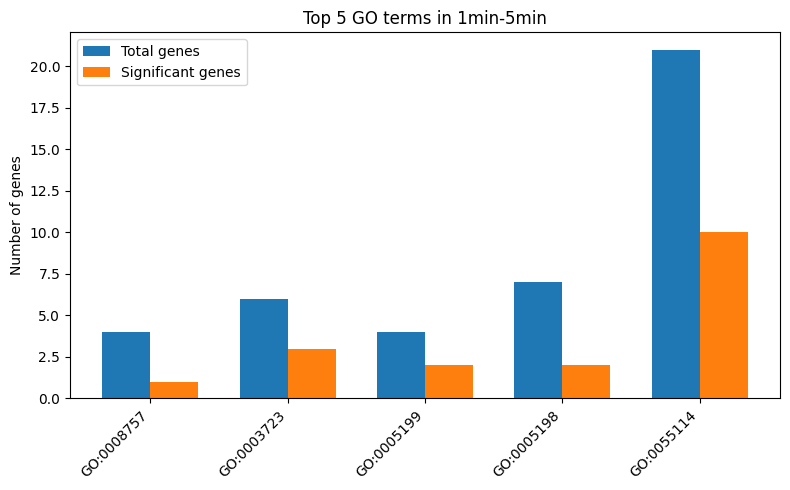

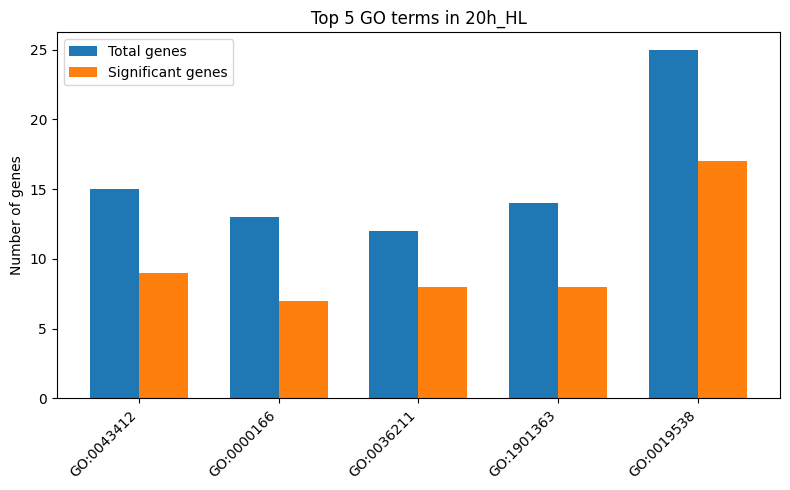

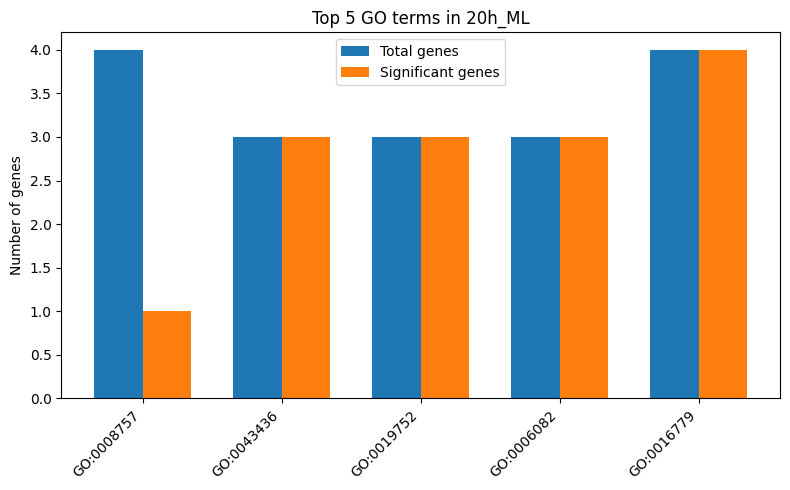

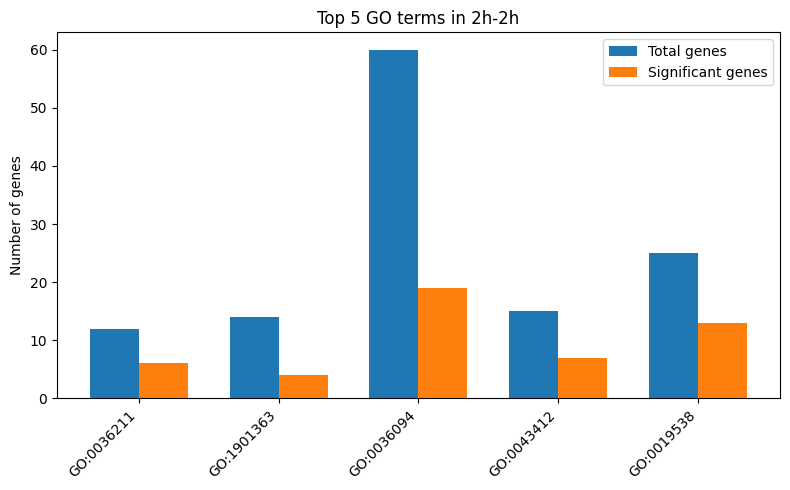

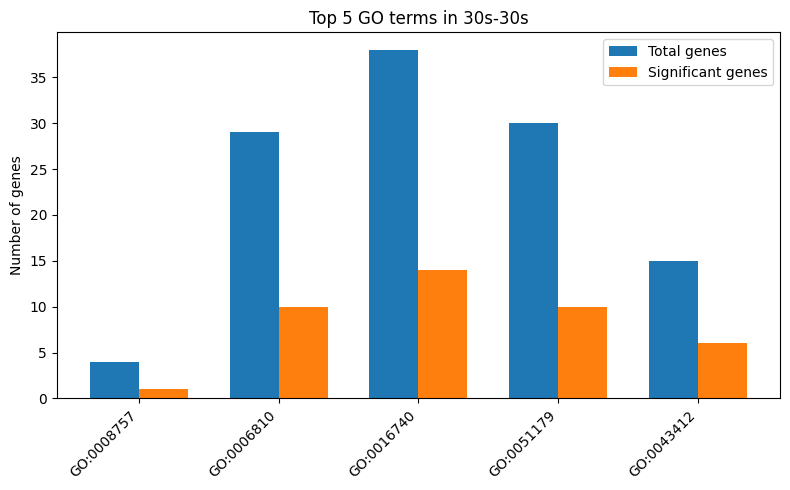

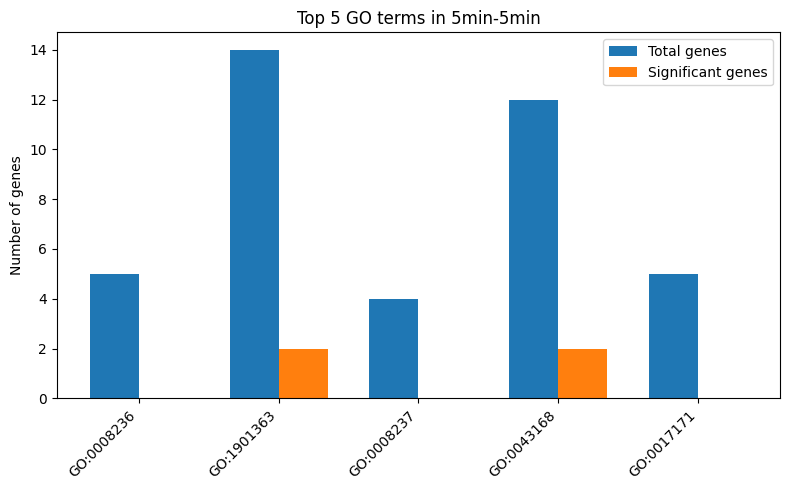

In [ ]:
def plot_top5_go(summary_go):
    regimes = summary_go['light_regime'].unique()
    for regime in regimes:
        df = (summary_go[summary_go['light_regime']==regime]
              .sort_values('p_adj')
              .head(5))

        x = np.arange(len(df))
        width = 0.35

        fig, ax = plt.subplots(figsize=(8,5))
        ax.bar(x - width/2, df['n_genes_in_X'], width, label="Total genes")
        ax.bar(x + width/2, df['n_sig_genes_overlap'], width, label="Significant genes")

        ax.set_xticks(x)
        ax.set_xticklabels(df['GO_term'], rotation=45, ha='right')
        ax.set_ylabel("Number of genes")
        ax.set_title(f"Top 5 GO terms in {regime}")
        ax.legend()
        plt.tight_layout()
        plt.show()

plot_top5_go(summary_go)


In [ ]:
signif_genes = pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/significant_genes.csv')
#signif_genes['p_adj'] = signif_genes['p_value']
#signif_genes['mutated_genes'] = signif_genes['mutant_ID']

signif_genes[signif_genes['p_adj']<0.05].groupby('light_regime')['mutated_genes'].nunique()
print(
    signif_genes[signif_genes['p_adj'] < 0.05]
    .groupby('light_regime')['mutated_genes']
    .nunique()
)
# significant gene sets per regime
sig_sets = (
    signif_genes[signif_genes['p_adj'] < 0.05]
    .groupby('light_regime')['mutated_genes']
    .apply(set)
)

# intersection between 1min-1min and 30s-30s
common_1min_30s = sig_sets['1min-1min'] & sig_sets['30s-30s']
print("Genes in both 1min and 30s:", len(common_1min_30s))

# intersection of 20h_HL with (1min, 30s)
common_20h = sig_sets['20h_HL'] & (sig_sets['1min-1min'] | sig_sets['30s-30s'])
print("Genes in 20h_HL and also in (1min or 30s):", len(common_20h))

# all significant genes across regimes
all_sig = set(
    signif_genes.loc[signif_genes['p_adj'] < 0.05, 'mutated_genes']
)
print("Total unique significant genes:", len(all_sig))


light_regime
10min-10min    166
1min-1min      277
1min-5min      174
20h_HL         449
20h_ML         376
2h-2h          233
30s-30s        202
5min-5min       44
Name: mutated_genes, dtype: int64
Genes in both 1min and 30s: 162
Genes in 20h_HL and also in (1min or 30s): 270
Total unique significant genes: 526


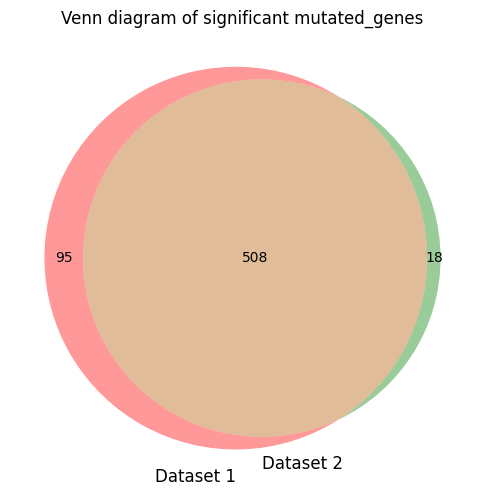

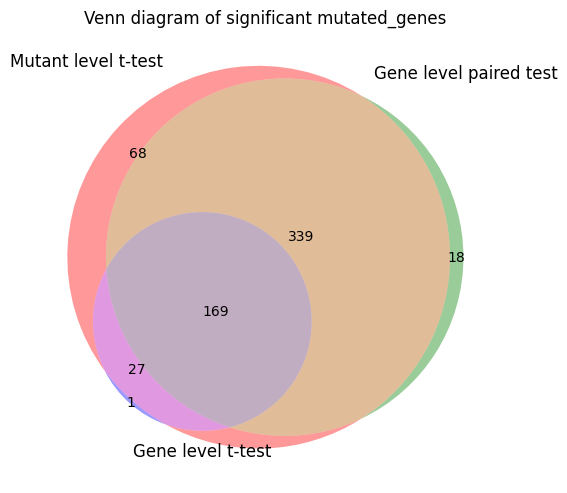

In [ ]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3
df1 = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/DifferentTestGenes/Allpvals_mutanttest_y2slope.csv')
df2 = pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/significant_genes.csv')
df3 = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/DifferentTestGenes/ttest_Genelevel_MeanMutReplicas.csv')
# Exemple avec deux DataFrames
genes1 = set(df1[df1['p_adj'] < 0.05]['mutated_genes'])
genes2 = set(df2[df2['p_adj'] < 0.05]['mutated_genes'])

plt.figure(figsize=(6,6))
venn2([genes1, genes2], set_labels=('Dataset 1', 'Dataset 2'))
plt.title("Venn diagram of significant mutated_genes")
plt.show()
genes3 = set(df3[df3['p_adj'] < 0.05]['mutated_genes'])

plt.figure(figsize=(6,6))
venn3([genes1, genes2, genes3], set_labels=('Mutant level t-test', 'Gene level paired test', 'Gene level t-test'))
plt.title("Venn diagram of significant mutated_genes")
plt.show()


In [ ]:
# Liste des gènes intéressants
interesting_genes = [ "Cre12.g531900","Cre16.g661200","Cre07.g314800","Cre13.g588150", "Cre06.g278110","Cre05.g235800","Cre02.g105350","Cre13.g581900", "Cre07.g323450","Cre15.g635800" ]

# Sets filtrés
genes1 = set(df1[(df1['p_adj'] < 0.05) & (df1['mutated_genes'].isin(interesting_genes))]['mutated_genes'])
genes2 = set(df2[(df2['p_adj'] < 0.05) & (df2['mutated_genes'].isin(interesting_genes))]['mutated_genes'])
genes3 = set(df3[(df3['p_adj'] < 0.05) & (df3['mutated_genes'].isin(interesting_genes))]['mutated_genes'])

# Comptes individuels
print(f"df1: {len(genes1)}")
print(f"df2: {len(genes2)}")
#print(f"df3: {len(genes3)}")

# Intersections
print(f"df1 ∩ df2: {len(genes1 & genes2)}")
print(f"df1 ∩ df3: {len(genes1 & genes3)}")
#print(f"df2 ∩ df3: {len(genes2 & genes3)}")
print(f"df1 ∩ df2 ∩ df3: {len(genes1 & genes2 & genes3)}")
print("Common to all three:", genes1 & genes2 )#& genes3)


df1: 9
df2: 8
df1 ∩ df2: 8
df1 ∩ df3: 4
df1 ∩ df2 ∩ df3: 4
Common to all three: {'Cre12.g531900', 'Cre13.g588150', 'Cre07.g314800', 'Cre16.g661200', 'Cre07.g323450', 'Cre15.g635800', 'Cre02.g105350', 'Cre05.g235800'}


### Enrichment ratio for each GO term among the top 5 from the test  (nb of significant genes from significant_genes.csv / total_nb_genes)

In [ ]:
# Enrichment ratio
df = pd.read_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/GO_pairedttest_results(min3gene).csv')
df['enrichment_ratio'] = df['n_sig_genes_overlap'] / df['n_genes_in_X']

# Top GO terms per light regime
top_go = (
    df.sort_values('enrichment_ratio', ascending=False)
      .groupby('light_regime')
      .head(7) 
)
print(top_go[['light_regime', 'GO_term', 'enrichment_ratio']])
go_desc_df = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/Go_kegg_path_panther_annot.csv')
top_go = top_go.merge(go_desc_df, left_on='GO_term', right_on='GO ID', how='left')
print(top_go[['light_regime', 'GO_term', 'GO Description', 'enrichment_ratio']])
top_go[['light_regime', 'GO_term', 'GO Description', 'enrichment_ratio']].to_csv('/Users/imanemokhtatif/Desktop/Carnegie/Chlamy_Project_v2-main/Data/GO_enrichment_ratio.csv')

     light_regime     GO_term  enrichment_ratio
1239        2h-2h  GO:0016779          1.000000
907        20h_ML  GO:0006082          1.000000
829        20h_HL  GO:0006082          1.000000
835        20h_HL  GO:0000160          1.000000
843        20h_HL  GO:0006979          1.000000
913        20h_ML  GO:0000160          1.000000
813        20h_HL  GO:0016758          1.000000
827        20h_HL  GO:0019752          1.000000
908        20h_ML  GO:0016779          1.000000
906        20h_ML  GO:0019752          1.000000
1386      30s-30s  GO:0016071          1.000000
905        20h_ML  GO:0043436          1.000000
791        20h_HL  GO:0016779          1.000000
919        20h_ML  GO:0006979          1.000000
826        20h_HL  GO:0043436          1.000000
1106       20h_ML  GO:0016772          0.769231
490     1min-5min  GO:0016779          0.750000
1361      30s-30s  GO:0005199          0.750000
1431      30s-30s  GO:0016779          0.750000
360     1min-1min  GO:0016779          0

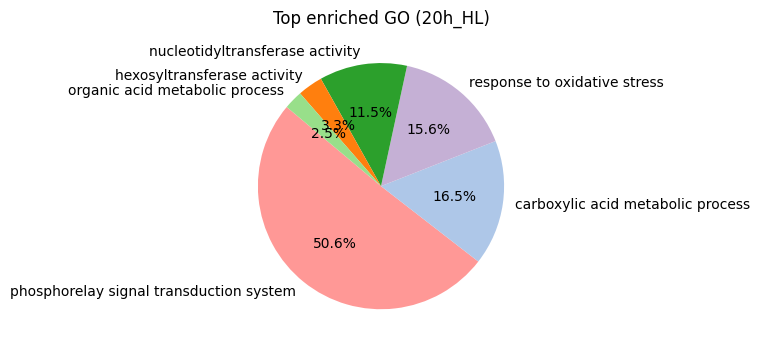

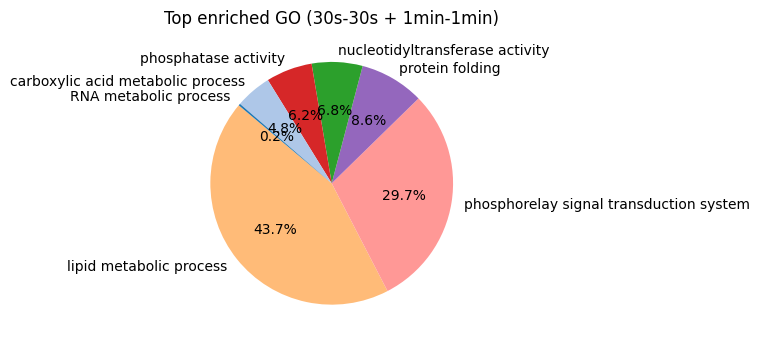

In [ ]:
import matplotlib.pyplot as plt

# Subset by regimes
top_go_HL = top_go[top_go['light_regime'] == '20h_HL']
top_go_FL = top_go[top_go['light_regime'].isin(['30s-30s','1min-1min'])]

# Count GO descriptions
desc_counts_HL = top_go_HL['GO Description'].value_counts()
desc_counts_FL = top_go_FL['GO Description'].value_counts()

# Build a consistent color map across both
all_descs = list(set(desc_counts_HL.index) | set(desc_counts_FL.index))
cmap = plt.get_cmap('tab20')
colors = {desc: cmap(i % cmap.N) for i, desc in enumerate(sorted(all_descs))}

# --- First plot: 20h_HL ---
plt.figure(figsize=(7, 7))
plt.pie(
    desc_counts_HL,
    labels=desc_counts_HL.index,
    colors=[colors[desc] for desc in desc_counts_HL.index],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Top enriched GO (20h_HL)")
plt.tight_layout()
plt.show()

# --- Second plot: 30s-30s & 1min-1min ---
plt.figure(figsize=(7, 7))
plt.pie(
    desc_counts_FL,
    labels=desc_counts_FL.index,
    colors=[colors[desc] for desc in desc_counts_FL.index],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Top enriched GO (30s-30s + 1min-1min)")
plt.tight_layout()
plt.show()
